In [57]:
import pandas as pd

# check df

In [58]:
import pandas as pd

dsc_xl = pd.ExcelFile('/Users/mauriellenoto/Desktop/seager/ionicliquids/isn/DSC/2026-07-13/2026-07-13-DSC-UAFW.xls')
dsc_df = pd.read_excel('/Users/mauriellenoto/Desktop/seager/ionicliquids/isn/DSC/2026-07-17/20260717-DSC-UAFW.xls', 
                          sheet_name="Ramp 10.00 °Cmin to 30.00 °C",
                          header =1
                          )
print(dsc_xl.sheet_names)
dsc_df.head()

['Details']


,Temperature,Heat Capacity (Normalized),Heat Flow (Normalized)
0,°C,J/(g.°C),W/g
1,-79.82,0,0.045216
2,-79.82,0,0.04524
3,-79.82,0,0.045175
4,-79.82,0,0.045119


# extract data fxn

In [36]:

# if you want a df of the details, use:
# details_df = pd.read_excel("path_to_excel_file", sheet_name = "Details", header = 1)

def extract_data(path): 
    # Read in original file 
    xl = pd.ExcelFile(path) 
    all_sheets = xl.sheet_names 
    print(all_sheets)
    
    data_sheets = all_sheets[1:] 
    df_list = [] 
    
    for sheet in data_sheets: 
        sheet_df = pd.read_excel(path, sheet_name=sheet, header=1) 
        
        # extract the units from the first row of data (index 0)
        units = sheet_df.iloc[0].fillna('').astype(str).tolist()
        
        # combine old column names with the units
        new_columns = []
        for col, unit in zip(sheet_df.columns, units):
            clean_col = col.split('.')[0] if '.' in col else col
            if unit:
                new_columns.append(f"{clean_col} ({unit})")
            else:
                new_columns.append(clean_col)
                
        # assign the new combined names back to the dataframe columns
        sheet_df.columns = new_columns
        
        # drop units row from the data
        sheet_df = sheet_df.drop(index=0).reset_index(drop=True)
        
        # add source sheet column
        sheet_df['Source Sheet'] = sheet 
        df_list.append(sheet_df) 
        
    # Vertically stack all the sheets together into one final df 
    combined_df = pd.concat(df_list, ignore_index=True)
    
    # convert to float
    # errors='coerce' turns any unconvertible text or bad data into NaN safely
    for col in combined_df.columns:
        if col != 'Source Sheet':
            combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')
    
    # make sure source sheet is last column in final df
    cols = [col for col in combined_df.columns if col != 'Source Sheet'] + ['Source Sheet']
    combined_df = combined_df[cols]
    
    return combined_df

In [59]:
dsc_df = extract_data('/Users/mauriellenoto/Desktop/seager/ionicliquids/isn/DSC/2026-07-17/20260717-DSC-UAFW.xls')
dsc_df.head()

['Details', 'Ramp 10.00 °Cmin to 30.00 °C']


,Temperature (°C),Heat Capacity (Normalized) (J/(g.°C)),Heat Flow (Normalized) (W/g),Source Sheet
0,-79.82,0.0,0.045216,Ramp 10.00 °Cmin to 30.00 °C
1,-79.82,0.0,0.045240,Ramp 10.00 °Cmin to 30.00 °C
2,-79.82,0.0,0.045175,Ramp 10.00 °Cmin to 30.00 °C
3,-79.82,0.0,0.045119,Ramp 10.00 °Cmin to 30.00 °C
4,-79.82,0.0,0.045033,Ramp 10.00 °Cmin to 30.00 °C


# single plot

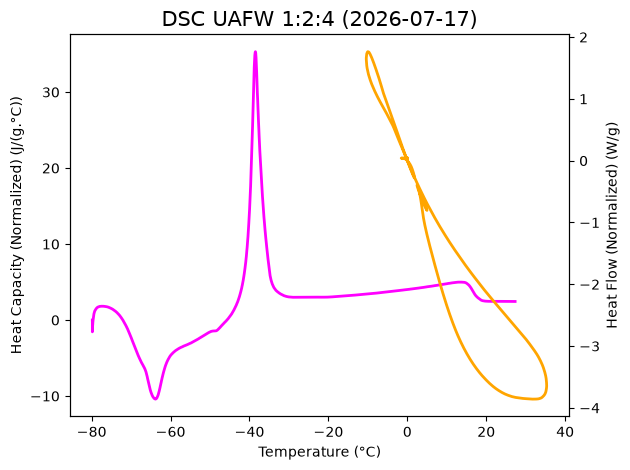

In [60]:
import matplotlib.pyplot as plt

dsc_cols = list(dsc_df.columns)

y1 = "magenta"
y2 = "orange"

fig, ax1 = plt.subplots()

heatflow_Wg = ax1.plot(dsc_df[dsc_cols[0]], dsc_df[dsc_cols[1]], color = y1, lw = 2, label = dsc_cols[1])
ax1.set_xlabel(dsc_cols[0])
ax1.set_ylabel(dsc_cols[1])
ax1.tick_params(axis='y')

ax2 = ax1.twinx()

heatflow_JgC = ax2.plot(dsc_df[dsc_cols[1]], dsc_df[dsc_cols[2]], color = y2, lw = 2, label = dsc_cols[2])
ax2.set_ylabel(dsc_cols[2])
ax2.tick_params(axis = 'y')

plt.title("DSC UAFW 1:2:4 (2026-07-17)", fontsize=15)
plt.tight_layout()
plt.show()

# multi plot

In [54]:
import matplotlib.pyplot as plt

def plot_multiple(df_list, x_col, y1_col, y2_col, titles=None, global_title=None):
    """
    Plots multiple DSC datasets in a grid of subplots using twin y-axes.
    
    Parameters:
    - df_list: List of pandas DataFrames (e.g., [df1, df2, df3])
    - x_col: Name of the column for the shared X axis (Temperature)
    - y1_col: Name of the column for the left Y axis (Heat Flow W/g)
    - y2_col: Name of the column for the right Y axis (Heat Flow J/gC)
    - titles: Optional list of strings for each subplot title
    """
    num_plots = len(df_list)
    if num_plots == 0:
        return
    

    nrows = 1 if num_plots <= 2 else 2
    ncols = num_plots if num_plots <= 2 else 2
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10 * ncols, 4 * nrows))
    

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    

    for i, df in enumerate(df_list):
        ax1 = axes[i]
        
        ax1.plot(df[x_col], df[y1_col], color="magenta", lw=2, label=y1_col)
        ax1.set_xlabel(x_col)
        ax1.set_ylabel(y1_col, color="magenta")
        ax1.tick_params(axis='y', labelcolor="magenta")
        
        ax2 = ax1.twinx()
        ax2.plot(df[x_col], df[y2_col], color="orange", lw=2, label=y2_col)
        ax2.set_ylabel(y2_col, color="orange")
        ax2.tick_params(axis='y', labelcolor="orange")
        
        # set individual subplot title
        if titles and i < len(titles):
            ax1.set_title(titles[i], fontsize=12)
        else:
            ax1.set_title(f"Dataset {i+1}", fontsize=12)
            
    # take out fourth subplot if three are passed in
    for j in range(num_plots, len(axes)):
        fig.delaxes(axes[j])

    # add suptitle
    if global_title:
        fig.suptitle(global_title, fontsize=16, fontweight='bold')
        # rect=[0, 0, 1, 0.95] keeps the subplots from crashing into the suptitle
        plt.tight_layout(rect=[0, 0, 1, 0.95])
    else:
        plt.tight_layout()
        
    plt.tight_layout()
    plt.show()


['Details', 'Ramp 10.00 °Cmin to 30.00 °C']


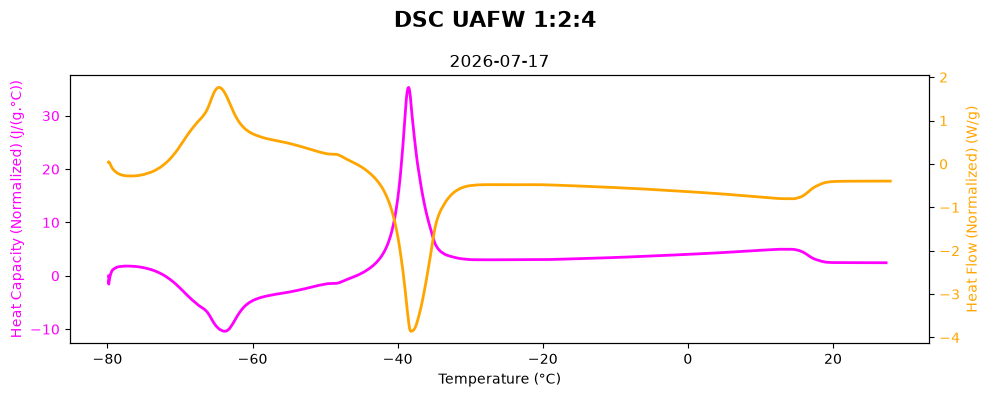

In [55]:
dsc_0717 = extract_data('/Users/mauriellenoto/Desktop/seager/ionicliquids/isn/DSC/2026-07-17/20260717-DSC-UAFW.xls')
# dsc_0713 = extract_data('/Users/mauriellenoto/Desktop/seager/ionicliquids/isn/DSC/2026-07-13/2026-07-13-DSC-UAFW.xls')

dataframes = [
            dsc_0717, 
            # dsc_0713,
            ]

df_titles = [
            "2026-07-17",
            # "2026-07-13",
            ]

df_columns = list(dsc_0717.columns)

plot_multiple(
            df_list= dataframes,
            x_col = df_columns[0],
            y1_col = df_columns[1],
            y2_col = df_columns[2],
            titles= df_titles,
            global_title= "DSC UAFW 1:2:4"

)